# 04 · CA-front-end byte-LM: multilingual pretraining (all six languages)

Track 2. A **vocabulary-free, UTF-8-byte, decoder-only** language model with a **causal
Neural Cellular Automaton (NCA) front-end**, pretrained from scratch jointly on all six NE-Indian
languages **+ English**. This is the from-scratch contribution measured against the IndicTrans2 / NLLB
baselines.

**The ablation that tests it (notes §5/§6) — one switch, `cfg.FRONTEND`:**
| value | front-end | role |
|---|---|---|
| `"nca"`  | **one** weight-shared causal-NCA update rule iterated `K` steps | the contribution |
| `"conv"` | `K` **distinct** causal-conv blocks (≈K× the params, same depth) | "is it the NCA, or just more conv?" |
| `"none"` | identity (raw byte embeddings → transformer) | "does any front-end help at all?" |

Run all three (same seed, same transformer) and compare **per-language bits-per-byte** — especially
Khasi & Nyishi, which **no pretrained model covers**. That per-language bpb curve is the headline plot.

### Why bytes, why *causal* NCA
- **Bytes** (vocab 256 + a few specials): any script is just bytes, so Khasi/Nyishi need **zero**
  vocab work, the thing that kills from-scratch models on unseen scripts.
- The front-end **must be causal** in a decoder-only next-byte LM, or it leaks future bytes into the
  representation used to predict them. So the NCA perceives **left neighbours only** -> information
  flows strictly past→future as the rule iterates. (A bidirectional NCA + prefix-LM is a documented
  alternative for the translation stage; see the last section.)

## 0 · Environment

In [1]:
import os, math, time, json, random
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

print("torch", torch.__version__, "| CUDA", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
# bf16 is well supported on A6000 (Ampere) -> no GradScaler needed
BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print("bf16 autocast:", BF16)

torch 2.8.0+cu128 | CUDA True | NVIDIA RTX A6000
bf16 autocast: True


## 1 · Config

`FRONTEND` is the ablation switch. Keep everything else fixed across the three runs so the comparison
is clean

In [2]:
from dataclasses import dataclass, field

@dataclass
class CFG:
    # ---- the ablation switch (run "nca", then "conv", then "none") ----
    FRONTEND: str = "nca"            # "nca" | "conv" | "none"
    SMOKE_TEST: bool = False         # True = tiny fast plumbing check (not a real run)

    seed: int = 42
    langs: tuple = ("Assamese","Khasi","Manipuri","Meitei-Mayek","Mizo","Nyishi")
    pretrain_english: bool = True    # also pretrain on the English side (helps the later En<->X tuning)
    data_dir: str = "data_clean"
    mono_dir: str = "mono_data"      # extra general-domain monolingual text per language (_fetch_mono.py)
    use_mono: bool = True            # augment TRAIN pretraining with mono_data/<lang>/*.txt
    out_dir:  str = "runs/ca_ncabig" # bigger-NCA run; 59M scale-up was runs/ca60, original 26M runs/ca

    # ---- transformer (the part that dominates the param count) ----
    d_model: int = 768               # 60M scale-up (was 512 -> 26M). still inside §5's 10-60M "tiny" range
    n_layers: int = 8
    n_heads: int = 12
    d_ff: int = 3072
    dropout: float = 0.1
    seq_len: int = 512               # bytes per block

    # ---- NCA front-end ----
    nca_steps: int = 12              # K: how many times the shared rule iterates (was 8)
    nca_hidden: int = 1536           # update-MLP hidden width — 2x d_model (was 768)
    nca_kernel: int = 5              # causal perception window: current + 4 left neighbours (was 3)
    nca_fire_rate: float = 0.5       # stochastic update (Growing-NCA style); 1.0 at eval

    # ---- optimisation ----
    batch_size: int = 32
    grad_accum: int = 2              # effective batch = batch_size * grad_accum
    lr: float = 3e-4
    min_lr_ratio: float = 0.1
    warmup_steps: int = 500
    weight_decay: float = 0.1
    betas: tuple = (0.9, 0.95)
    grad_clip: float = 1.0
    max_steps: int = 40000           # <- scale this to fill your 1-2 day budget
    gpu: int = 0

    # ---- in-training tracking (so you can watch it learn) ----
    eval_every: int = 1000           # per-language val bits-per-byte
    gen_every: int = 2000            # sample generations per language
    n_val_blocks: int = 40           # val blocks per language for bpb estimate
    ckpt_every: int = 2000

    def __post_init__(self):
        if self.SMOKE_TEST:
            self.d_model=128; self.n_layers=2; self.n_heads=4; self.d_ff=512; self.seq_len=128
            self.nca_steps=4; self.nca_hidden=128
            self.batch_size=16; self.grad_accum=1; self.max_steps=60
            self.warmup_steps=10; self.eval_every=20; self.gen_every=30
            self.n_val_blocks=8; self.ckpt_every=1000

cfg = CFG()
assert cfg.FRONTEND in ("nca","conv","none")
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
DEVICE = f"cuda:{cfg.gpu}" if torch.cuda.is_available() else "cpu"
RUN_DIR = os.path.join(cfg.out_dir, cfg.FRONTEND)
os.makedirs(RUN_DIR, exist_ok=True)
print(f"FRONTEND={cfg.FRONTEND} | SMOKE={cfg.SMOKE_TEST} | device={DEVICE} | run_dir={RUN_DIR}")

FRONTEND=nca | SMOKE=False | device=cuda:0 | run_dir=runs/ca_ncabig/nca


## 2 · Byte vocabulary, language tags & data packing

Vocab = 256 raw byte values + a few specials. Each sentence becomes
`[<LANG tag>] + utf8_bytes + [EOS]`; we concatenate everything and chunk into fixed `seq_len` blocks
(standard LM packing). The **language tag** is what conditions generation and what a later
"`Translate to Khasi:`" prompt will key on.

The TRAIN stream is the parallel-corpus target text **plus general-domain monolingual text**
(Wikipedia + GlotCC, fetched by `_fetch_mono.py` into `mono_data/<lang>/`) to dilute the parallel
data's register skew. Toggle with `cfg.use_mono`. **Nyishi is the exception**: the web
has almost no Nyishi text, so it stays reliant on its (large, 46k-pair) parallel corpus.

In [3]:
# ---- vocabulary ----
PAD, BOS, EOS = 256, 257, 258
TAG_NAMES = (["English"] if cfg.pretrain_english else []) + list(cfg.langs)
LANG_TAG = {name: 259 + i for i, name in enumerate(TAG_NAMES)}     # one id per language
VOCAB = 259 + len(TAG_NAMES)
print("vocab size:", VOCAB, "| language tags:", LANG_TAG)

import pandas as pd, wmt_data as D
# TRAIN ON ALL DATA (2026-06-15): per-language text = target side of ALL parallel pairs (data_clean
# train+dev+test + the 2025 gold, via wmt_data) + scraped monolingual (mono_data/). English = the
# deduped English side of all pairs. No held-out split (final ckpt; real eval = blind 2026 gold).
def build_train_text():
    out = {name: [] for name in TAG_NAMES}
    for lang in cfg.langs:
        out[lang] = [t for _, t in D.parallel_pairs(lang)] + (D.mono_texts(lang) if cfg.use_mono else [])
    if cfg.pretrain_english:
        out["English"] = D.english_pairs_pool(cfg.langs)
    return out

def encode(text, tag_id):
    return [tag_id] + list(text.encode("utf-8")) + [EOS]

train_txt = build_train_text()
print("train sentences per tag (all parallel + mono):", {k: len(v) for k, v in train_txt.items()})

vocab size: 266 | language tags: {'English': 259, 'Assamese': 260, 'Khasi': 261, 'Manipuri': 262, 'Meitei-Mayek': 263, 'Mizo': 264, 'Nyishi': 265}
train sentences per tag (all parallel + mono): {'English': 198733, 'Assamese': 5461917, 'Khasi': 46848, 'Manipuri': 87265, 'Meitei-Mayek': 83860, 'Mizo': 150210, 'Nyishi': 51984}


In [4]:
# ---- pack train text into one big 1-D byte stream, then into blocks ----
def pack_stream(txt_by_tag, cap_per_tag=None):
    stream = []
    for name, sents in txt_by_tag.items():
        if cap_per_tag: sents = sents[:cap_per_tag]
        tag = LANG_TAG[name]
        for s in sents:
            stream.extend(encode(s, tag))
    return np.array(stream, dtype=np.int16)

cap = 2000 if cfg.SMOKE_TEST else None
rng = np.random.default_rng(cfg.seed)
stream = pack_stream(train_txt, cap_per_tag=cap)
n_blocks = len(stream) // cfg.seq_len
stream = stream[:n_blocks * cfg.seq_len].reshape(n_blocks, cfg.seq_len)
print(f"train stream: {n_blocks:,} blocks x {cfg.seq_len} bytes  (~{len(stream.flatten())/1e6:.1f}M bytes)")

def get_batch(bs):
    idx = rng.integers(0, n_blocks, size=bs)
    blk = torch.from_numpy(stream[idx].astype(np.int64))     # [bs, seq_len]
    return blk[:, :-1].to(DEVICE), blk[:, 1:].to(DEVICE)     # (inputs, targets)

xb, yb = get_batch(4)
print("batch:", xb.shape, yb.shape, "| dtype", xb.dtype)

train stream: 2,327,151 blocks x 512 bytes  (~1191.5M bytes)
batch: torch.Size([4, 511]) torch.Size([4, 511]) | dtype torch.int64


In [5]:
# ---- per-language MONITOR blocks (no held-out split -> sampled from TRAINING text; progress only) ----
def lang_val_blocks(name, n_blocks_cap):
    tag = LANG_TAG[name]
    s = []
    for t in train_txt[name][:4000]:           # small sample of training text (monitoring, not a clean val)
        s.extend(encode(t, tag))
    s = np.array(s, dtype=np.int16)
    nb_ = max(1, len(s) // cfg.seq_len)
    s = s[:nb_ * cfg.seq_len].reshape(nb_, cfg.seq_len)
    if len(s) > n_blocks_cap: s = s[:n_blocks_cap]
    return torch.from_numpy(s.astype(np.int64))

VAL = {name: lang_val_blocks(name, cfg.n_val_blocks) for name in TAG_NAMES}
print("monitor blocks per language (train-set, no holdout):", {k: len(v) for k, v in VAL.items()})

monitor blocks per language (train-set, no holdout): {'English': 40, 'Assamese': 40, 'Khasi': 40, 'Manipuri': 40, 'Meitei-Mayek': 40, 'Mizo': 40, 'Nyishi': 40}


## 3 · Architecture

**Causal NCA front-end.** State `s` starts as the byte+position embedding. Each of `K` steps applies
**one shared rule**: perceive left neighbours via a *causal* depthwise conv, concatenate with the
(layernormed) state, and an MLP emits a **residual** update: `s ← s + Δ`. The update MLP is **zero-
initialised** so the NCA starts as a do-nothing identity and *grows* structure gradually (the standard
NCA init that makes iterated updates stable). Stochastic per-cell updates (`fire_rate`) during training,
full updates at eval. Weight-shared across both space and steps → the NCA's hallmark tiny param count.

In [6]:
class CausalNCA(nn.Module):
    """One weight-shared local update rule, iterated K steps, left-looking (causal)."""
    def __init__(self, d, hidden, steps, kernel, fire_rate):
        super().__init__()
        self.steps, self.fire_rate, self.pad = steps, fire_rate, kernel - 1
        self.norm = nn.LayerNorm(d)
        self.perceive = nn.Conv1d(d, d, kernel_size=kernel, groups=d, bias=False)  # depthwise, causal via left pad
        self.fc1 = nn.Linear(2 * d, hidden)
        self.fc2 = nn.Linear(hidden, d)
        nn.init.zeros_(self.fc2.weight); nn.init.zeros_(self.fc2.bias)              # start = identity
    def forward(self, s):
        for _ in range(self.steps):
            sn = self.norm(s)
            p = F.pad(sn.transpose(1, 2), (self.pad, 0))          # left-pad only -> no future leakage
            p = self.perceive(p).transpose(1, 2)
            delta = self.fc2(F.gelu(self.fc1(torch.cat([sn, p], dim=-1))))
            if self.training and self.fire_rate < 1.0:
                mask = (torch.rand(s.shape[:2], device=s.device) <= self.fire_rate).unsqueeze(-1)
                delta = delta * mask
            s = s + delta
        return s

class CausalConvStack(nn.Module):
    """Control: K DISTINCT causal-conv blocks (no weight sharing) -> ~K x the NCA params, same depth."""
    def __init__(self, d, hidden, steps, kernel, **_):
        super().__init__()
        self.pad = kernel - 1
        self.blocks = nn.ModuleList()
        for _ in range(steps):
            self.blocks.append(nn.ModuleDict(dict(
                norm=nn.LayerNorm(d),
                perceive=nn.Conv1d(d, d, kernel_size=kernel, groups=d, bias=False),
                fc1=nn.Linear(2 * d, hidden), fc2=nn.Linear(hidden, d))))
        for b in self.blocks:
            nn.init.zeros_(b["fc2"].weight); nn.init.zeros_(b["fc2"].bias)
    def forward(self, s):
        for b in self.blocks:
            sn = b["norm"](s)
            p = F.pad(sn.transpose(1, 2), (self.pad, 0))
            p = b["perceive"](p).transpose(1, 2)
            s = s + b["fc2"](F.gelu(b["fc1"](torch.cat([sn, p], dim=-1))))
        return s

def build_frontend(cfg):
    if cfg.FRONTEND == "nca":
        return CausalNCA(cfg.d_model, cfg.nca_hidden, cfg.nca_steps, cfg.nca_kernel, cfg.nca_fire_rate)
    if cfg.FRONTEND == "conv":
        return CausalConvStack(cfg.d_model, cfg.nca_hidden, cfg.nca_steps, cfg.nca_kernel)
    return nn.Identity()

**Decoder-only transformer.** Pre-norm blocks, causal self-attention via
`F.scaled_dot_product_attention` (flash kernels when available), learned positional embeddings, weight-
tied byte head. Standard small-GPT; the only novelty lives in the front-end above.

In [7]:
class Block(nn.Module):
    def __init__(self, d, nh, dff, dropout):
        super().__init__()
        self.nh, self.hd = nh, d // nh
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d); self.proj = nn.Linear(d, d)
        self.mlp = nn.Sequential(nn.Linear(d, dff), nn.GELU(), nn.Linear(dff, d), nn.Dropout(dropout))
        self.drop = nn.Dropout(dropout); self.ad = dropout
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(self.ln1(x)).split(C, dim=2)
        q = q.view(B, T, self.nh, self.hd).transpose(1, 2)
        k = k.view(B, T, self.nh, self.hd).transpose(1, 2)
        v = v.view(B, T, self.nh, self.hd).transpose(1, 2)
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=self.ad if self.training else 0.0)
        a = a.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.drop(self.proj(a))
        x = x + self.mlp(self.ln2(x))
        return x

class CAByteLM(nn.Module):
    def __init__(self, cfg, vocab):
        super().__init__()
        self.cfg = cfg
        self.tok = nn.Embedding(vocab, cfg.d_model)
        self.pos = nn.Embedding(cfg.seq_len, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.frontend = build_frontend(cfg)
        self.blocks = nn.ModuleList([Block(cfg.d_model, cfg.n_heads, cfg.d_ff, cfg.dropout)
                                     for _ in range(cfg.n_layers)])
        self.lnf = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, vocab, bias=False)
        self.head.weight = self.tok.weight                          # weight tying
        self.apply(self._init)
        # re-zero the NCA/conv output projection AFTER global init (keep do-nothing front-end)
        if isinstance(self.frontend, CausalNCA):
            nn.init.zeros_(self.frontend.fc2.weight); nn.init.zeros_(self.frontend.fc2.bias)
        elif isinstance(self.frontend, CausalConvStack):
            for b in self.frontend.blocks:
                nn.init.zeros_(b["fc2"].weight); nn.init.zeros_(b["fc2"].bias)
    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, std=0.02)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok(idx) + self.pos(pos))
        x = self.frontend(x)                                        # causal -> no leakage
        for b in self.blocks: x = b(x)
        logits = self.head(self.lnf(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1),
                                   ignore_index=PAD)
        return logits, loss

## 4 · Instantiate & count parameters

In [8]:
model = CAByteLM(cfg, VOCAB).to(DEVICE)
def n_params(mod): return sum(p.numel() for p in mod.parameters())
tot = n_params(model); fe = n_params(model.frontend); tr = tot - fe - n_params(model.tok)
print(f"TOTAL params      : {tot/1e6:6.2f} M")
print(f"  front-end ({cfg.FRONTEND:4s}): {fe/1e6:6.3f} M")
print(f"  transformer     : {tr/1e6:6.2f} M")
print(f"  byte embed (tied): {n_params(model.tok)/1e6:6.3f} M")
if not (10e6 <= tot <= 120e6):
    print(f"  [warn] {tot/1e6:.1f}M is outside the ~10-120M working range — adjust d_model/n_layers.")

TOTAL params      :  60.85 M
  front-end (nca ):  3.547 M
  transformer     :  57.10 M
  byte embed (tied):  0.204 M


## 5 · Tracking utilities: per-language bits-per-byte & sampling

**Bits-per-byte (bpb)** is the comparable cross-entropy unit for a byte model (`nats / ln2`, measured
only over real byte positions, not the tag). Lower = the model predicts that language's bytes better.
We track it **per language** every `eval_every` steps, the Khasi/Nyishi curves are the whole point.

In [9]:
@torch.no_grad()
def bits_per_byte(blocks):
    model.eval()
    fr = None
    if isinstance(model.frontend, CausalNCA):                  # full (deterministic) updates at eval
        fr = model.frontend.fire_rate; model.frontend.fire_rate = 1.0
    tot_nll, tot_bytes = 0.0, 0
    for i in range(0, len(blocks), cfg.batch_size):
        blk = blocks[i:i+cfg.batch_size].to(DEVICE)
        x, y = blk[:, :-1], blk[:, 1:]
        with torch.autocast("cuda", dtype=torch.bfloat16, enabled=BF16):
            logits, _ = model(x)
        nll = F.cross_entropy(logits.reshape(-1, VOCAB).float(), y.reshape(-1),
                              ignore_index=PAD, reduction="sum")
        tot_nll += nll.item(); tot_bytes += (y != PAD).sum().item()
    if fr is not None: model.frontend.fire_rate = fr
    model.train()
    return tot_nll / tot_bytes / math.log(2)                   # bits per byte

def eval_all_langs():
    return {name: round(bits_per_byte(VAL[name]), 3) for name in TAG_NAMES}

In [10]:
@torch.no_grad()
def generate(lang, n_bytes=160, temp=0.8, top_k=40):
    model.eval()
    fr = None
    if isinstance(model.frontend, CausalNCA):
        fr = model.frontend.fire_rate; model.frontend.fire_rate = 1.0   # deterministic at eval, restored below
    idx = torch.tensor([[LANG_TAG[lang]]], device=DEVICE)
    for _ in range(n_bytes):
        ctx = idx[:, -cfg.seq_len:]
        with torch.autocast("cuda", dtype=torch.bfloat16, enabled=BF16):
            logits, _ = model(ctx)
        logits = logits[:, -1, :].float() / temp
        if top_k:
            v, _ = torch.topk(logits, top_k); logits[logits < v[:, [-1]]] = -float("inf")
        nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
        if nxt.item() == EOS: break
        idx = torch.cat([idx, nxt], dim=1)
    if fr is not None: model.frontend.fire_rate = fr   # restore stochastic NCA for continued training
    model.train()
    by = bytes([t for t in idx[0].tolist() if t < 256])
    return by.decode("utf-8", errors="replace")

def show_samples(langs=None):
    for name in (langs or TAG_NAMES):
        print(f"  [{name:12s}] {generate(name)!r}")

## 6 · Pretraining loop

AdamW (decoupled weight decay only on 2-D matrices), cosine LR with warmup, bf16 autocast, grad-accum,
grad clipping. Every `eval_every` steps it prints **per-language bpb** and redraws the curves; every
`gen_every` it samples each language so you can literally watch script-correct bytes emerge, including
for Khasi/Nyishi. Best (lowest mean-bpb) checkpoint is saved to `RUN_DIR`.

In [11]:
def make_optimizer(model, cfg):
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        (decay if p.dim() >= 2 else no_decay).append(p)
    return torch.optim.AdamW([{"params": decay, "weight_decay": cfg.weight_decay},
                              {"params": no_decay, "weight_decay": 0.0}],
                             lr=cfg.lr, betas=cfg.betas)

def lr_at(step, cfg):
    if step < cfg.warmup_steps: return cfg.lr * (step + 1) / cfg.warmup_steps
    prog = (step - cfg.warmup_steps) / max(1, cfg.max_steps - cfg.warmup_steps)
    return cfg.lr * (cfg.min_lr_ratio + 0.5 * (1 - cfg.min_lr_ratio) * (1 + math.cos(math.pi * prog)))

opt = make_optimizer(model, cfg)
hist = {"step": [], "train_loss": [], "bpb": {n: [] for n in TAG_NAMES}, "bpb_step": []}
best_mean = float("inf")

In [12]:
def plot_progress():
    from IPython.display import clear_output
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(hist["step"], hist["train_loss"], lw=.8, color="#444")
    ax[0].set_title(f"train loss ({cfg.FRONTEND})"); ax[0].set_xlabel("step"); ax[0].set_ylabel("CE (nats)")
    if hist["bpb_step"]:
        for n in TAG_NAMES:
            style = "o-" if n in ("Khasi", "Nyishi") else "-"     # highlight the unseen-script langs
            lw = 2.2 if n in ("Khasi", "Nyishi") else 1.0
            ax[1].plot(hist["bpb_step"], hist["bpb"][n], style, lw=lw, label=n)
        ax[1].set_title("val bits-per-byte (lower=better)"); ax[1].set_xlabel("step"); ax[1].set_ylabel("bpb")
        ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.show()

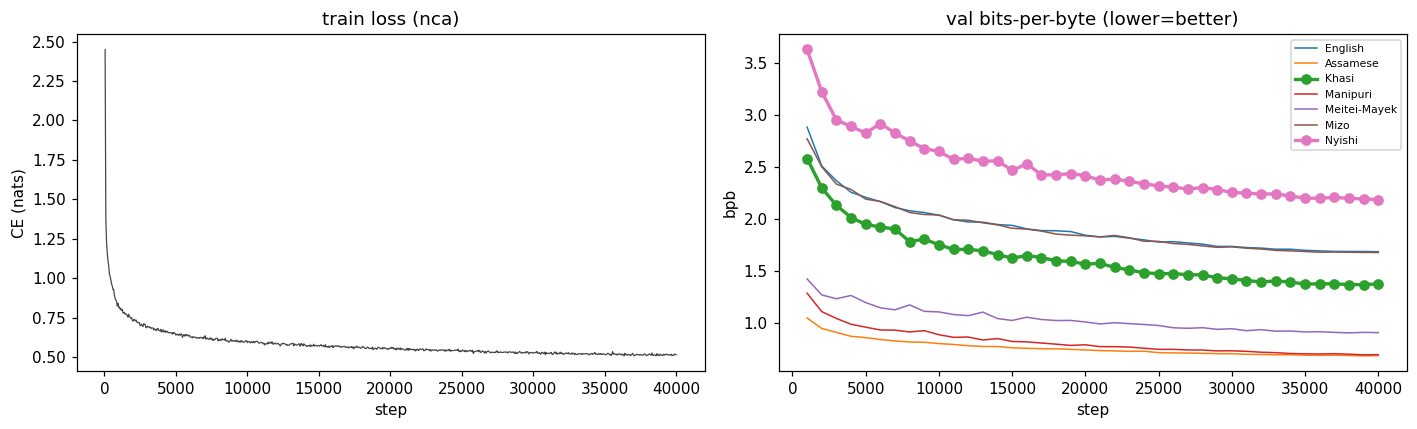

step  40000 |   2.6 it/s | mean bpb 1.314 | Khasi 1.374 Nyishi 2.186
   per-lang bpb: {'English': 1.684, 'Assamese': 0.682, 'Khasi': 1.374, 'Manipuri': 0.691, 'Meitei-Mayek': 0.903, 'Mizo': 1.676, 'Nyishi': 2.186}
   samples:
  [English     ] 'So love me , I will be my bread .'
  [Assamese    ] 'এই ক্ষেত্ৰত সহায় কৰা প্ৰয়াসৰ বিষয়।'
  [Khasi       ] 'Ki bwara bwa thang awa nayaba ina yaka kaba wan hakalamwa kaba tom kilodi lamwe na mangi yateni anu.'
  [Manipuri    ] 'স্কুলশিং অমসুং মখোয়গী পুক্নিং অমা লৈরি।'
  [Meitei-Mayek] 'নেসন্সিএল মেদিকেল ফোরাম পীজর চহি কী বাতকী খুদমনি অদুনা য়াই�'
  [Mizo        ] 'Berai tau\\nনিয়মীয়া বাতৰি ওলালে এটা চিঠি (Control region) আনি দিবলৈ বৰ্তমান�'
  [Nyishi      ] 'Hureo, ngog anye godvb tumpa v ngog benam ngo mwwpaml doonum hoge nyindo, hog akhognam hoge nyis godoukke, ngo vc pogba ngam goodo tuma,'
done in 261.0 min | best mean bpb 1.314


In [13]:
print(f"=== pretraining FRONTEND={cfg.FRONTEND} | {n_params(model)/1e6:.1f}M params | "
      f"max_steps={cfg.max_steps} | eff.batch={cfg.batch_size*cfg.grad_accum} ===")
model.train(); t0 = time.time(); running = 0.0
for step in range(cfg.max_steps):
    for g in opt.param_groups: g["lr"] = lr_at(step, cfg)
    opt.zero_grad(set_to_none=True)
    for _ in range(cfg.grad_accum):
        x, y = get_batch(cfg.batch_size)
        with torch.autocast("cuda", dtype=torch.bfloat16, enabled=BF16):
            _, loss = model(x, y)
        (loss / cfg.grad_accum).backward()
        running += loss.item() / cfg.grad_accum
    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
    opt.step()

    if (step + 1) % 50 == 0:
        hist["step"].append(step + 1); hist["train_loss"].append(running / 50); running = 0.0

    if (step + 1) % cfg.eval_every == 0 or step == cfg.max_steps - 1:
        bpb = eval_all_langs(); mean_bpb = float(np.mean(list(bpb.values())))
        hist["bpb_step"].append(step + 1)
        for n in TAG_NAMES: hist["bpb"][n].append(bpb[n])
        dt = time.time() - t0; sps = (step + 1) / dt
        plot_progress()
        print(f"step {step+1:6d} | {sps:5.1f} it/s | mean bpb {mean_bpb:.3f} | "
              f"Khasi {bpb.get('Khasi','-')} Nyishi {bpb.get('Nyishi','-')}")
        print("   per-lang bpb:", bpb)
        if mean_bpb < best_mean:
            best_mean = mean_bpb
            torch.save({"model": model.state_dict(), "cfg": cfg.__dict__, "vocab": VOCAB,
                        "lang_tag": LANG_TAG, "step": step + 1, "bpb": bpb},
                       os.path.join(RUN_DIR, "best.pt"))

    if (step + 1) % cfg.gen_every == 0:
        print("   samples:"); show_samples()

print(f"done in {(time.time()-t0)/60:.1f} min | best mean bpb {best_mean:.3f}")

## 7 · Post-training diagnostics

best @ step 40000 | mean bpb 1.314


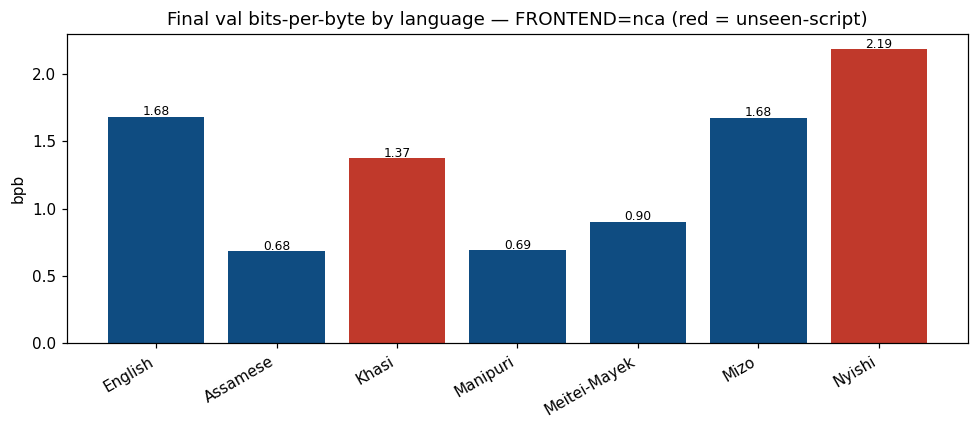

In [15]:
# final per-language bpb (load best ckpt)
ck = torch.load(os.path.join(RUN_DIR, "best.pt"), map_location=DEVICE)
model.load_state_dict(ck["model"]); final_bpb = ck["bpb"]
print(f"best @ step {ck['step']} | mean bpb {np.mean(list(final_bpb.values())):.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
names = list(final_bpb); vals = [final_bpb[n] for n in names]
colors = ["#c0392b" if n in ("Khasi","Nyishi") else "#0f4c81" for n in names]
ax.bar(names, vals, color=colors)
ax.set_title(f"Final val bits-per-byte by language — FRONTEND={cfg.FRONTEND} (red = unseen-script)")
ax.set_ylabel("bpb"); plt.xticks(rotation=30, ha="right")
for i, v in enumerate(vals): ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

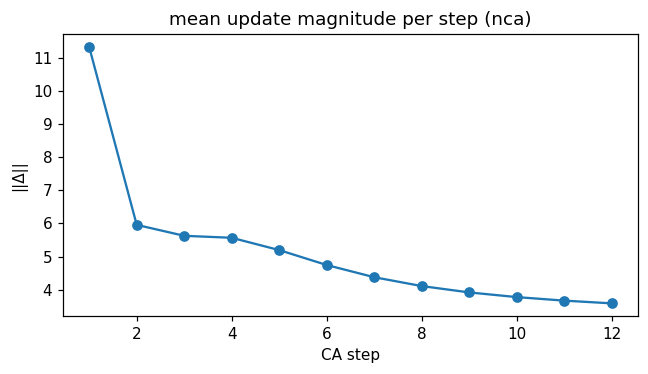

In [16]:
# NCA "growth": how much each iterated step changes the representation (only meaningful for nca/conv)
if cfg.FRONTEND in ("nca", "conv"):
    model.eval()
    if isinstance(model.frontend, CausalNCA): model.frontend.fire_rate = 1.0
    x, _ = get_batch(8)
    with torch.no_grad():
        s = model.drop(model.tok(x) + model.pos(torch.arange(x.size(1), device=DEVICE)))
        deltas = []
        fe = model.frontend
        steps = fe.steps if isinstance(fe, CausalNCA) else len(fe.blocks)
        for k in range(steps):
            if isinstance(fe, CausalNCA):
                sn = fe.norm(s); p = F.pad(sn.transpose(1,2),(fe.pad,0)); p = fe.perceive(p).transpose(1,2)
                d = fe.fc2(F.gelu(fe.fc1(torch.cat([sn,p],-1))))
            else:
                b = fe.blocks[k]; sn = b["norm"](s); p = F.pad(sn.transpose(1,2),(fe.pad,0))
                p = b["perceive"](p).transpose(1,2); d = b["fc2"](F.gelu(b["fc1"](torch.cat([sn,p],-1))))
            deltas.append(d.norm(dim=-1).mean().item()); s = s + d
    plt.figure(figsize=(6,3.5)); plt.plot(range(1, steps+1), deltas, "o-")
    plt.title(f"mean update magnitude per step ({cfg.FRONTEND})"); plt.xlabel("CA step"); plt.ylabel("||Δ||")
    plt.tight_layout(); plt.show()
    model.train()
else:
    print("FRONTEND='none' — no front-end to inspect.")

## 8 · Save run + the ablation comparison

In [17]:
# persist this run's metrics so the three front-ends can be compared side by side
with open(os.path.join(RUN_DIR, "metrics.json"), "w") as f:
    json.dump({"frontend": cfg.FRONTEND, "params_M": round(n_params(model)/1e6, 3),
               "best_step": ck["step"], "final_bpb": final_bpb,
               "mean_bpb": round(float(np.mean(list(final_bpb.values()))), 4),
               "history": hist, "cfg": cfg.__dict__}, f, ensure_ascii=False, indent=2)
print("saved", os.path.join(RUN_DIR, "metrics.json"), "+ best.pt")

saved runs/ca_ncabig/nca/metrics.json + best.pt


### Per-language bpb across front-ends

In [18]:
import glob
runs = {}
for mp in glob.glob(os.path.join(cfg.out_dir, "*", "metrics.json")):
    m = json.load(open(mp)); runs[m["frontend"]] = m
if len(runs) >= 2:
    langs = list(next(iter(runs.values()))["final_bpb"])
    fig, ax = plt.subplots(figsize=(11, 4.5)); x = np.arange(len(langs)); w = 0.8/len(runs)
    for i, (fe, m) in enumerate(sorted(runs.items())):
        ax.bar(x + i*w, [m["final_bpb"][l] for l in langs], w,
               label=f"{fe} ({m['params_M']}M)")
    ax.set_xticks(x + w*(len(runs)-1)/2); ax.set_xticklabels(langs, rotation=30, ha="right")
    ax.set_ylabel("val bits-per-byte (lower better)"); ax.legend()
    ax.set_title("Front-end ablation — per-language bpb (the §5 experiment)")
    plt.tight_layout(); plt.show()
    print(pd.DataFrame({fe: m["final_bpb"] for fe, m in runs.items()}))
else:
    print("Only", list(runs), "found — run the other front-ends to populate the comparison.")

Only ['nca'] found — run the other front-ends to populate the comparison.


## 8b · Push the pretrained base to the Hugging Face Hub *(optional)*

In [19]:
PUSH = False                                       # <- set True to upload
REPO = "sujayrittikar/ca-byte-lm-indic6"           # the pretrained-base repo

if PUSH:
    import shutil
    from huggingface_hub import HfApi
    exp = os.path.join(RUN_DIR, "hf_export"); shutil.rmtree(exp, ignore_errors=True); os.makedirs(exp)
    shutil.copy(os.path.join(RUN_DIR, "best.pt"), os.path.join(exp, "ca_byte_lm.pt"))
    shutil.copy("ca_byte_lm.py", os.path.join(exp, "ca_byte_lm.py"))   # importable architecture
    shutil.copy(os.path.join(RUN_DIR, "metrics.json"), os.path.join(exp, "metrics.json"))
    json.dump({"architecture": "CAByteLM", "vocab": VOCAB, "lang_tag": LANG_TAG, **cfg.__dict__},
              open(os.path.join(exp, "config.json"), "w"), ensure_ascii=False, indent=2)
    rows = "\n".join(f"| {k} | {v} |" for k, v in final_bpb.items())
    open(os.path.join(exp, "README.md"), "w").write(f"""---
license: cc-by-sa-4.0
language: [as, kha, lus, mni, en]
library_name: pytorch
tags: [byte-level, neural-cellular-automata, low-resource, indic, wmt]
pipeline_tag: text-generation
---

# CA-front-end byte-LM — pretrained base ({cfg.FRONTEND}, {n_params(model)/1e6:.0f}M)

Vocabulary-free, UTF-8-byte, decoder-only LM with a causal Neural-CA front-end, pretrained jointly on
six NE-Indian languages + English. The shared base that the En↔X translators are fine-tuned from.

## Validation bits-per-byte (best @ step {ck['step']})
| language | val bpb |
|---|---|
{rows}

## Usage
```python
from ca_byte_lm import from_hub, generate
model, cfg, meta = from_hub("{REPO}", device="cuda")
print(generate(model, cfg, meta["lang_tag"]["Khasi"], device="cuda"))
```
""")
    api = HfApi(); api.create_repo(REPO, exist_ok=True, repo_type="model")
    api.upload_folder(folder_path=exp, repo_id=REPO, repo_type="model",
                      commit_message=f"Pretrained base ({cfg.FRONTEND}, {n_params(model)/1e6:.0f}M)")
    print("pushed ->", f"https://huggingface.co/{REPO}")
else:
    print("set PUSH=True to upload ->", REPO)

set PUSH=True to upload -> sujayrittikar/ca-byte-lm-indic6
